# Tennessee Eastman Process — Adaption

Adaptiert das in *tep_model* trainierte MLP an den Fehlerfallstrom (IDV 29) mit vier
Strategien (Baseline, Passiv, Aktiv, Kombiniert) sowie der passiven Strategie mit
Recurrence-Selektor (`blind_rec`, Masterarbeit Abschn. 5.5.3: Rückholung vergangener
Punkte mit ähnlichem Fehler); Module `drift_adaptation.py` / `drift_detection.py`.

Die Einteilung folgt Gama et al. (2014, Abschn. 3.3.2): *blind* = rein periodisches
Nachtraining ohne Fehlerauswertung, *informed* = trigger-basiert. Als Trigger werden
alle fünf Detektoren gescreent — die vier statistischen Verfahren sowie der
Schwellwert-Detektor `RMSE`, der die Überwachung eines Performance-Indikators
(Gama Abschn. 3.2) in ihrer einfachsten Form darstellt. Die aktive und die
kombinierte Strategie werden anschließend mit dem im Screening besten Detektor
ausgewertet.

Aufbau und Kaskade sind deckungsgleich zu *syn_adaptation*; TEP-spezifisch sind
lediglich die Datenquelle (`data_scored_error`, Zielgröße `cost`), die
Abtastrate (`SAMPLES_PER_H`) und das Betriebspunktsignal `mode`, aus dem die
stationäre Phasendauer $T_\mathrm{stat}$ geschätzt wird. Das Driftsignal wird
nicht rekonstruiert, sondern als Spalte `driftf` gelesen (wie in *tep_detection*).

In [1]:
FORCE_RECOMPUTE = True   # True = alle Cache-Stufen neu rechnen (Tuning + nachgelagerte Laeufe)
IS_FINAL = True           # True: schreibt zusaetzlich den stabilen, eingebundenen Stand

In [2]:
# --- Konstanten ---
RUN_ID =  "629ff00f" # None          # None -> neuestes Modell
ERROR_VARIANT = {"idv": 29, "amp": 0.3} # None   # None -> neuester Fehlerfall; sonst z. B. {"idv": 29, "amp": 0.3}

SEED = 44

SAMPLES_PER_H = 20           # Abtastung des TEP-Rohstroms (alle 3 min)
SAMPLE_S = 3600 // SAMPLES_PER_H   # 180 s je Rohpunkt

# Adaptions- und Tuningraster analog syn_adaptation, dort 600 s / 3600 s auf einem
# 60-s-Rohstrom (Faktor 10 bzw. 60). Der TEP-Rohstrom ist mit 180 s bereits
# groeber; STEP_S = 1800 s haelt den Adaptionsstrom bei rund 35 000 Punkten und
# STEP_TUNE_S = 10800 s das Tuningraster bei rund 5 800 -- dasselbe Verhaeltnis
# STRIDE_TUNE / STRIDE = 6 wie im synthetischen Fall.
STEP_S = 1800                # Abtastung des Adaptionsstroms
STEP_TUNE_S = 10800          # groebere Abtastung fuers Tuning
DETECTORS = ("KSWIN", "ADWIN", "DDM", "EDDM", "RMSE")
N_TRIALS = {"screening": 40, "final": 60}
TUNE_WEIGHTS = (1.0, 0.1)
# Refraktaerzeit zwischen zwei Sofort-Trainings (x * T_stat); cooldown wird als cooldown_x in [0, 60] getunt
COOLDOWN_X = 30
# Update-Validierung: Nachtraining verwerfen, wenn der MSE nicht sinkt
REJECT = True

# Bekannte gute Betriebspunkte eines frueheren Laufs, je Fall als Startkandidat
# eingereiht (enqueue): TPE zieht unabhaengig von der Trial-Zahl nur
# n_startup_trials = 10 Zufallspunkte und findet ein schmales gutes Becken sonst
# nicht; ein eingereihter Punkt konkurriert regulaer mit den uebrigen Trials, das
# Ergebnis kann dadurch nie schlechter werden als die Referenz. Fuer den TEP gibt
# es noch keinen solchen Stand -- nach dem ersten vollstaendigen Lauf die Optima
# aus results/tep_adaptation.json ("tuning" -> "best_params") hier eintragen.
# Achtung: nur Werte INNERHALB des Suchraums von _suggest_adapt_params einreihen,
# Optuna klemmt einen Ausreisser nicht, sondern benutzt ihn unveraendert.
REFERENCE_PARAMS = {}

N_SEED_RUNS = 50             # Zielzahl an Laeufen mit identischer Konfiguration

PLOT_FRAC = 0.05             # Anteil geplotteter Punkte
PLOT_YLIM = (-1e2, 1e2)      # symlog-Bereich der Fehlerachse
PLOT_EPOCH = "1970-01-01"    # Zeitstempel-Ursprung wie im synthetischen Fall
PLOT_MONTHS = 6              # None -> ganzer Strom

In [3]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "tep"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

## Daten und Basismodell laden

In [4]:
import numpy as np
import pandas as pd
from src.utils import run_registry as rr
rr.assert_current()   # veraltetes Modul im Kernel? (s. drift_adaptation)

ledger = rr.run_ledger(work_dir)
data_store = rr.tep_data_store(data_dir)
model_store = rr.tep_model_store(model_dir)
plot_store = rr.tep_plot_store(plot_dir, ledger=ledger)
res_store = rr.tep_results_store(results_dir, ledger=ledger)

rng = np.random.default_rng(SEED)

_mp = model_store.latest("model")
if _mp is None:
    raise FileNotFoundError("Kein model-Artefakt. Bitte tep_model.ipynb ausfuehren.")
model_id = model_store.parse_id(_mp, "model") if RUN_ID is None else RUN_ID
_mc = model_store.load("model", run_id=model_id, rename=True)
base_model, feature_cols = _mc["model"], _mc["feature_cols"]

test_scored = data_store.load("data_scored_production", run_id=model_id, rename=True)
model_cfg = rr.RunConfig.from_document(test_scored.attrs.get("config", test_scored.attrs))

error_scored, scored_error_cfg = rr.load_section(
    data_store, "data_scored_error", model_cfg, "error", ERROR_VARIANT)
error_variant = scored_error_cfg.sections["error"]
ledger.bind("adaptation", parents={"model": scored_error_cfg.id})

# Gemeinsamer Kopf aller Cache-Schluessel dieses Notebooks (Modell + Fehlerfall).
base_cfg = model_cfg.compose(error=error_variant)
print(f"model_id = {model_id} | error_run_id = {scored_error_cfg.id} "
      f"(IDV {error_variant['idv']}, amp {error_variant['amp']})")

model_id = 629ff00f | error_run_id = 5d29a9f2 (IDV 29, amp 0.3)


In [5]:
STRIDE = max(1, STEP_S // SAMPLE_S)
stream = error_scored.iloc[::STRIDE].copy()
N = len(stream)

X_cd = stream[feature_cols].to_numpy(dtype="float32")
y_cd = stream["cost"].to_numpy(dtype="float32")

# Driftsignal aus den Daten, nicht rekonstruiert: driftf = Stripper Temp(Fehler) /
# Stripper Temp(nominal) aus tep_generation, punktweise exakt (wie tep_detection).
cd_signal = stream["driftf"].to_numpy(dtype=float) - 1.0
# Segmentnummer des Saegezahns: die Ruecksprungstellen kommen aus dieser Spalte
# und nicht aus einer Schwelle auf c(t) -- das gemessene Signal rauscht, ein
# Kriterium auf diff traefe tausende Scheingrenzen (s. tep_detection).
drift_segment = stream["drift_segment"].to_numpy(dtype=float)
reset_pos = np.flatnonzero(stream["reset"].to_numpy())

# Darstellungszeit als Zeitstempel, analog tep_detection und syn_adaptation.
t_h = np.arange(N) * STRIDE / SAMPLES_PER_H
time_index = pd.to_datetime(t_h * 3600.0, unit="s", origin=pd.Timestamp(PLOT_EPOCH))

print(f"Adaptionsstrom: {N} Punkte (STEP={STEP_S}s, STRIDE={STRIDE}, "
      f"{N * STRIDE / SAMPLES_PER_H:.0f} h), {len(reset_pos) + 1} Laeufe")
print(f"Driftsignal (gemessen): min={np.nanmin(cd_signal):.3f}, max={np.nanmax(cd_signal):.3f}")

Adaptionsstrom: 34849 Punkte (STEP=1800s, STRIDE=10, 17424 h), 1 Laeufe
Driftsignal (gemessen): min=-0.138, max=0.147


## Adaptionsstrategien

In [6]:
import tensorflow as tf
import drift_adaptation as da
from drift_adaptation import run_adaptation, StreamingDetector

# Ein laufender Kernel haelt das Modul fest; assert_current bricht ab, wenn die
# Datei inzwischen abweicht. SPACE_ID kommt aus dem GELADENEN Code-Objekt und
# geht in die Cache-Schluessel ein, damit eine geaenderte Grenze in
# _suggest_adapt_params den Cache verwirft statt ihn stillschweigend zu treffen.
da.assert_current()
SPACE_ID = da.adapt_space_id()
print(f"Suchraum-Kennung: {SPACE_ID}")

Suchraum-Kennung: c3683005


## Detektor-Konfiguration (für die Informed-Adaption)

Die Detektorparameter werden **nicht** aus *tep_detection* übernommen, sondern im geschlossenen Regelkreis mitgetunt (`_suggest_adapt_params` in `drift_adaptation.py`): das Fehlerniveau nach einem Nachtraining unterscheidet sich vom statischen Fehlerstrom des Detektions-Notebooks, dort kalibrierte Werte sind hier systematisch fehlangepasst.

`make_detector` liefert deshalb nur die Hülle; `apply_det_params` setzt vor jedem Trial und jedem Lauf die getunten Werte. Ein Warmstart aus `tep_detection.json` wäre zudem in zweifacher Hinsicht unbrauchbar: er überträgt Schrittzahlen vom 180-s-Rohraster auf das `STEP_TUNE_S`-Raster, und für DDM und EDDM läge sein `err_threshold` außerhalb des hier gesuchten Bereichs — Optuna benutzt einen solchen Wert unverändert weiter, statt ihn zu begrenzen, und verzerrt damit die erste Beobachtung.

In [7]:
import json   # fuer das Scannen des Seed-Archivs weiter unten


def make_detector(name):
    """Frischer StreamingDetector aus den Modul-Defaults von drift_detection.py.

    Konstruktionswerte bleiben ohne Wirkung: apply_det_params ueberschreibt vor
    jedem Lauf saemtliche Detektorparameter mit den im Adaptions-Tuning
    optimierten (s. Markdown darueber).
    """
    return StreamingDetector(name)


def detector_factory(name):
    return lambda: make_detector(name)

In [8]:
# Normierungs-Baseline aus dem drift-FREIEN Produktionsstrom, analog zu
# tep_detection. Die Praediktionen liegen als Spalte y_pred vor, ein erneuter
# model.predict-Lauf eruebrigt sich. Vorzeichen beachten: tep_model legt
# model_error = y_pred - cost ab, run_adaptation bildet den Fehler dagegen als
# y - pred; die Baseline wird deshalb aus cost - y_pred gebildet (gleiche
# Streuung wie in tep_detection, Mittelwert mit umgekehrtem Vorzeichen).
_base_free_err = (test_scored["cost"] - test_scored["y_pred"]).to_numpy(dtype=float)
NORM_MEAN = float(np.nanmean(_base_free_err))
NORM_STD = float(np.nanstd(_base_free_err)) or 1.0
print(f"Normierungs-Baseline: mean={NORM_MEAN:.4g}, std={NORM_STD:.4g}")

Normierungs-Baseline: mean=-0.005654, std=0.02027


## Hyperparameter-Tuning der Adaption

In [9]:
STRIDE_TUNE = max(1, STEP_TUNE_S // SAMPLE_S)

_tune = error_scored.iloc[::STRIDE_TUNE]
X_tune = _tune[feature_cols].to_numpy(dtype="float32")
y_tune = _tune["cost"].to_numpy(dtype="float32")

# Stationaere Phasendauer aus dem Betriebspunktsignal: im TEP wechselt der
# Betriebspunkt ueber die Spalte "mode" (im synthetischen Fall die Sollwerte
# w1/w2). estimate_cooldown zaehlt die Wechsel und teilt die Stromlaenge.
_, T_STAT_TUNE = da.estimate_cooldown(_tune[["mode"]], x=COOLDOWN_X)

CHUNK_TUNE = max(24, 86400 // STEP_TUNE_S)
TUNE_FIXED = dict(chunk=CHUNK_TUNE, reject=REJECT,
                  norm_mean=NORM_MEAN, norm_std=NORM_STD, seed=SEED)
print(f"Tuningstrom: {len(X_tune)} Punkte (STRIDE_TUNE={STRIDE_TUNE}) | "
      f"chunk={CHUNK_TUNE} | T_stat(tune) ~ {T_STAT_TUNE:.0f} Punkte")

best_adapt_params, studies, tune_cfgs = {}, {}, {}

def _tune_case(key, strategy, n_trials, det_name=None, enqueue=None, extra_cfg=None):
    """Tunt einen Fall und cached ihn ueber die RunConfig-Kennung."""
    tune_params = {"method": strategy, "case": key, "n_trials": n_trials,
                   "weights": list(TUNE_WEIGHTS), "step_tune_s": STEP_TUNE_S,
                   "step_s": STEP_S, "space": SPACE_ID,
                   "reference": REFERENCE_PARAMS.get(key),
                   "scheme": "phase-extend", "cooldown_tuned": True,
                   **({"detector": det_name} if det_name else {}),
                   **(extra_cfg or {}),
                   **{k: TUNE_FIXED[k] for k in sorted(TUNE_FIXED)
                      if not k.startswith("norm_")}}
    tune_cfgs[key] = base_cfg.compose(tuning=tune_params)
    if (model_store.exists("adapt_tuning", tune_cfgs[key], rekey=True)
            and not FORCE_RECOMPUTE):
        best_adapt_params[key] = model_store.load("adapt_tuning", tune_cfgs[key], rekey=True)
        print(f"{key:18s} aus Cache")
        return
    tf.keras.utils.set_random_seed(SEED)
    # Referenzpunkt eines frueheren Laufs voranstellen (s. REFERENCE_PARAMS).
    _ref = REFERENCE_PARAMS.get(key)
    if _ref is not None:
        enqueue = [da.encode_adapt_params(_ref)] + list(enqueue or [])
    _fac = detector_factory(det_name) if det_name else None
    _study, _ = da.tune_adaptation(strategy, base_model, X_tune, y_tune,
                                   fixed=TUNE_FIXED, detector_factory=_fac,
                                   n_trials=n_trials, weights=TUNE_WEIGHTS,
                                   seed=SEED, enqueue=enqueue, t_stat=T_STAT_TUNE)
    studies[key] = _study
    best_adapt_params[key] = da.decode_adapt_params(_study.best_params)
    _a = _study.best_trial.user_attrs
    print(f"{key:18s} score={_study.best_value:.3f} | rmse={_a['rmse']:.3f} "
          f"n_train={_a['n_train']:3d} n_detect={_a['n_detect']:3d}")
    model_store.save(best_adapt_params[key], "adapt_tuning", tune_cfgs[key])

# --- Passive Strategie (detektorfrei, finale Konfiguration direkt) ---
_tune_case("blind", "blind", N_TRIALS["final"])
# Recurrence-Selektor auf der passiven Strategie; das blind-Optimum wird als
# Teilkandidat eingereiht (fehlende Selektorparameter zieht Optuna selbst).
_tune_case("blind_rec", "blind_rec", N_TRIALS["final"],
           enqueue=[da.encode_adapt_params(best_adapt_params["blind"])])

# --- Screening: informierte Strategie je Detektor, reduziertes Budget ---
# Ohne Warmstart: jeder Detektor startet unter denselben Bedingungen, sonst
# waere der Vergleich, aus dem BEST_DETECTOR folgt, nicht fair.
print(f"\nDetektor-Screening ({N_TRIALS['screening']} Trials je Detektor)")
for _det in DETECTORS:
    _tune_case(f"informed@{_det}", "informed", N_TRIALS["screening"], det_name=_det)

Tuningstrom: 5809 Punkte (STRIDE_TUNE=60) | chunk=24 | T_stat(tune) ~ 48 Punkte


[I 2026-09-06 20:07:17,159] A new study created in memory with name: no-name-c21d8203-3d4a-4a22-bd29-f3b821859804
[I 2026-09-06 20:07:25,886] Trial 0 finished with value: 1.1194885249037716 and parameters: {'lr': 0.006556811559955235, 'epochs': 4, 'freeze': 'TTF', 'reset': False, 'blind_window': 172, 'blind_period': 379}. Best is trial 0 with value: 1.1194885249037716.
[I 2026-09-06 20:07:47,975] Trial 1 finished with value: 1.9080931916250647 and parameters: {'lr': 0.0035103210706085753, 'epochs': 29, 'freeze': 'TTF', 'reset': True, 'blind_window': 379, 'blind_period': 638}. Best is trial 0 with value: 1.1194885249037716.
[I 2026-09-06 20:07:57,494] Trial 2 finished with value: 1.1256618821967774 and parameters: {'lr': 0.0025506353511792726, 'epochs': 7, 'freeze': 'TTF', 'reset': False, 'blind_window': 271, 'blind_period': 625}. Best is trial 0 with value: 1.1194885249037716.
[I 2026-09-06 20:08:17,428] Trial 3 finished with value: 1.0032921810699589 and parameters: {'lr': 0.000210817

blind              score=1.003 | rmse=0.040 n_train=  8 n_detect=  0


[I 2026-09-06 20:22:31,176] A new study created in memory with name: no-name-b970615e-79a1-4fb2-aad4-13ab93cec1a9
[I 2026-09-06 20:22:42,020] Trial 0 finished with value: 1.0032921810699589 and parameters: {'lr': 0.0002108176504891831, 'epochs': 17, 'freeze': 'TFF', 'reset': True, 'blind_window': 321, 'blind_period': 714, 'err_tol': 1.5256173352547486, 'rec_horizon': 44, 'rec_max': 302}. Best is trial 0 with value: 1.0032921810699589.
[I 2026-09-06 20:22:58,862] Trial 1 finished with value: 1.0065843621399178 and parameters: {'lr': 0.0006088113196073895, 'epochs': 11, 'freeze': 'TTF', 'reset': True, 'blind_window': 385, 'blind_period': 342, 'err_tol': 0.28800437909541315, 'rec_horizon': 46, 'rec_max': 99}. Best is trial 0 with value: 1.0032921810699589.
[I 2026-09-06 20:23:14,960] Trial 2 finished with value: 1.0453608271762138 and parameters: {'lr': 0.012121227439373649, 'epochs': 29, 'freeze': 'TTF', 'reset': False, 'blind_window': 192, 'blind_period': 633, 'err_tol': 0.1440567918769

blind_rec          score=0.926 | rmse=0.037 n_train= 16 n_detect=  0

Detektor-Screening (40 Trials je Detektor)


...

informed@DDM       score=1.002 | rmse=0.040 n_train=  4 n_detect= 14


[I 2026-09-06 21:13:23,509] A new study created in memory with name: no-name-a6a9b3e1-5cca-400d-91a7-71a2bf14c1e6
[I 2026-09-06 21:13:30,448] Trial 0 finished with value: 1.0098765432098766 and parameters: {'lr': 0.006556811559955235, 'epochs': 4, 'freeze': 'TFF', 'reset': True, 'window_prev': 121, 'window_post': 126, 'cooldown_x': 30.594144575376387, 'det_alpha': 0.9761016914728389, 'det_beta': 0.9691502929627389, 'det_min_num_misclassified_instances': 102, 'det_err_threshold': 1.355303042123218}. Best is trial 0 with value: 1.0098765432098766.
[I 2026-09-06 21:14:00,913] Trial 1 finished with value: 1.0730852300662577 and parameters: {'lr': 0.00017656611781643403, 'epochs': 7, 'freeze': 'TFF', 'reset': False, 'window_prev': 68, 'window_post': 193, 'cooldown_x': 8.34877511909421, 'det_alpha': 0.9562376215541236, 'det_beta': 0.9365303056125339, 'det_min_num_misclassified_instances': 66, 'det_err_threshold': 1.8297021955250632}. Best is trial 0 with value: 1.0098765432098766.
[I 2026-09

informed@EDDM      score=0.993 | rmse=0.039 n_train= 12 n_detect= 17


[I 2026-09-06 21:21:31,136] A new study created in memory with name: no-name-4dbbe6d2-dcb5-4c7a-a2f8-3a325a753708
[I 2026-09-06 21:21:38,154] Trial 0 finished with value: 6.353899874618088 and parameters: {'lr': 0.006556811559955235, 'epochs': 4, 'freeze': 'TFF', 'reset': True, 'window_prev': 121, 'window_post': 126, 'cooldown_x': 30.594144575376387, 'det_window': 73, 'det_threshold': 2.9013155630141685}. Best is trial 0 with value: 6.353899874618088.
[I 2026-09-06 21:22:09,570] Trial 1 finished with value: 1.246438804862112 and parameters: {'lr': 0.0009854831519119712, 'epochs': 13, 'freeze': 'FFF', 'reset': False, 'window_prev': 266, 'window_post': 196, 'cooldown_x': 12.829488727836512, 'det_window': 66, 'det_threshold': 0.8478656299622587}. Best is trial 1 with value: 1.246438804862112.
[I 2026-09-06 21:22:56,167] Trial 2 finished with value: 1.2024933265028994 and parameters: {'lr': 0.000995822461515799, 'epochs': 27, 'freeze': 'FFF', 'reset': False, 'window_prev': 171, 'window_pos

informed@RMSE      score=1.006 | rmse=0.040 n_train= 14 n_detect= 14


In [10]:
# Gegenpruefung des Screenings auf dem voll aufgeloesten Strom. Ausgewaehlt wird
# der Detektor mit dem kleinsten RMSE eines vollstaendigen Adaptionslaufs; das
# Tuning laeuft auf einem groeber abgetasteten Strom, die Uebertragung der
# Konfiguration ist daher eine Extrapolation und muss geprueft werden.
_RESCALE = STRIDE_TUNE / STRIDE
CHUNK = max(24, 86400 // STEP_S)
_BASE_CFG = dict(chunk=CHUNK, reject=REJECT, norm_mean=NORM_MEAN, norm_std=NORM_STD)
COOLDOWN, T_stat = da.estimate_cooldown(stream[["mode"]], x=COOLDOWN_X)

_scr_cfg = base_cfg.compose(screening={
    "detectors": sorted(DETECTORS), "step_s": STEP_S, "cooldown_x": COOLDOWN_X,
    "space": SPACE_ID,
    "rescale": _RESCALE, "reject": REJECT,
    "params": {d: da.encode_adapt_params(best_adapt_params[f"informed@{d}"])
               for d in DETECTORS}})

if model_store.exists("adapt_screening", _scr_cfg, rekey=True) and not FORCE_RECOMPUTE:
    screening = model_store.load("adapt_screening", _scr_cfg, rekey=True)
    print("Screening aus Cache")
else:
    screening = {}
    for _det in DETECTORS:
        _key = f"informed@{_det}"
        _, _tab = da.crosscheck_candidates(
            base_model, X_cd, y_cd,
            best_params={"informed": best_adapt_params[_key]}, fixed=_BASE_CFG,
            t_stat=T_stat, detector_factory=detector_factory(_det),
            study=None, top_k=0, rescale=_RESCALE, mode="informed", seed=SEED,
            verbose=False)
        screening[_det] = _tab["tpe_best"]
        print(f"{_det:6s} RMSE={_tab['tpe_best']['rmse']:.4f}  "
            f"n_train={_tab['tpe_best']['n_train']}")

    model_store.save(screening, "adapt_screening", _scr_cfg)

BEST_DETECTOR = min(screening, key=lambda d: screening[d]["rmse"])
print(f"\nGewaehlter Detektor: {BEST_DETECTOR} "
      f"(RMSE={screening[BEST_DETECTOR]['rmse']:.4f})")

screening_table = pd.DataFrame(
    {d: {"rmse": v["rmse"], "n_train": v["n_train"]} for d, v in screening.items()}).T

KSWIN  RMSE=0.0398  n_train=11
ADWIN  RMSE=0.0547  n_train=49
DDM    RMSE=0.0398  n_train=8
EDDM   RMSE=0.0393  n_train=28
RMSE   RMSE=0.2632  n_train=57

Gewaehlter Detektor: EDDM (RMSE=0.0393)


In [11]:
# Der gewaehlte Detektor wird mit vollem Budget nachgetunt (Warmstart mit dem
# Screening-Optimum), danach die kombinierte Strategie mit demselben Detektor
# (Warmstart mit der Vereinigung der Einzeloptima).
_scr = best_adapt_params[f"informed@{BEST_DETECTOR}"]
_tune_case("informed", "informed", N_TRIALS["final"], det_name=BEST_DETECTOR,
           enqueue=[da.encode_adapt_params(_scr)])

_bl, _inf = best_adapt_params["blind"], best_adapt_params["informed"]
_tune_case("combined", "combined", N_TRIALS["final"], det_name=BEST_DETECTOR,
           enqueue=[da.encode_adapt_params({**_bl, **_inf}),
                    da.encode_adapt_params({**_inf, **_bl})])

# --- Gegenpruefung auf voller Aufloesung -------------------------------------
# Eigener Cache-Fall: der Crosscheck darf NICHT nach "adapt_tuning" zurueck-
# schreiben, sonst laedt _tune_case beim naechsten Lauf sein eigenes Ergebnis
# und die Gegenpruefung startet von einem anderen Kandidatensatz.
# Der Schluessel haengt an den TPE-Optima (= Eingang), damit er inhalts-
# adressiert und ueber Laeufe hinweg stabil ist.
_CC_KEYS = ("blind", "informed", "combined", "blind_rec")
_cc_cfg = base_cfg.compose(crosscheck={
    "detector": BEST_DETECTOR,
    "space": SPACE_ID,
    "step_s": STEP_S,
    "cooldown_x": COOLDOWN_X,
    "rescale": float(_RESCALE),
    "reject": REJECT,
    "chunk": CHUNK,
    "top_k": 3,
    "tpe": {k: da.encode_adapt_params(best_adapt_params[k]) for k in _CC_KEYS},
})

if model_store.exists("adapt_crosscheck", _cc_cfg, rekey=True) and not FORCE_RECOMPUTE:
    best_adapt_params.update(model_store.load("adapt_crosscheck", _cc_cfg, rekey=True))
    print(f"Crosscheck aus Cache ({BEST_DETECTOR})")
    for _m in _CC_KEYS:
        print(f"  {_m:9s} {best_adapt_params[_m]}")
else:
    # informed zuerst, da der union-Kandidat der kombinierten Strategie dessen
    # Optimum nutzt.
    _extra = {"informed": {"combined_cfg": dict(best_adapt_params["combined"]),
                           "screening_cfg": dict(_scr)}}
    for _m in ("informed", "combined"):
        print(f"--- {_m} ({BEST_DETECTOR}) ---")
        best_adapt_params[_m], _ = da.crosscheck_candidates(
            base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
            t_stat=T_stat, detector_factory=detector_factory(BEST_DETECTOR),
            study=studies.get(_m), rescale=_RESCALE, mode=_m, seed=SEED,
            extra=_extra.get(_m))

    # Die passive Strategie ebenfalls gegenpruefen (blind_period wird mitskaliert)
    print("--- blind ---")
    best_adapt_params["blind"], _ = da.crosscheck_candidates(
        base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
        t_stat=T_stat, detector_factory=None, study=studies.get("blind"),
        rescale=_RESCALE, mode="blind", seed=SEED)
    print("--- blind_rec ---")
    best_adapt_params["blind_rec"], _ = da.crosscheck_candidates(
        base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
        t_stat=T_stat, detector_factory=None, study=studies.get("blind_rec"),
        rescale=_RESCALE, mode="blind_rec", seed=SEED)

    model_store.save({k: best_adapt_params[k] for k in _CC_KEYS},
                     "adapt_crosscheck", _cc_cfg)

[I 2026-09-06 21:45:35,174] A new study created in memory with name: no-name-325c980b-614a-4f00-bafd-b8073562821b
[I 2026-09-06 21:45:40,991] Trial 0 finished with value: 0.9932954038965713 and parameters: {'lr': 0.0002956235801433969, 'epochs': 6, 'freeze': 'FFF', 'reset': False, 'window_prev': 77, 'window_post': 68, 'cooldown_x': 47.881925173671384, 'det_alpha': 0.9932582568233524, 'det_beta': 0.929603037627838, 'det_min_num_misclassified_instances': 92, 'det_err_threshold': 1.6552904699422057}. Best is trial 0 with value: 0.9932954038965713.
[I 2026-09-06 21:45:47,423] Trial 1 finished with value: 1.0098765432098766 and parameters: {'lr': 0.006556811559955235, 'epochs': 4, 'freeze': 'TFF', 'reset': True, 'window_prev': 121, 'window_post': 126, 'cooldown_x': 30.594144575376387, 'det_alpha': 0.9761016914728389, 'det_beta': 0.9691502929627389, 'det_min_num_misclassified_instances': 102, 'det_err_threshold': 1.355303042123218}. Best is trial 0 with value: 0.9932954038965713.
[I 2026-09-

informed           score=0.956 | rmse=0.038 n_train= 16 n_detect= 10


[I 2026-09-06 21:56:13,531] A new study created in memory with name: no-name-fddc4f1e-a585-4c01-aea6-a0e754bca8f2
[I 2026-09-06 21:56:21,160] Trial 0 finished with value: 1.0364270545720582 and parameters: {'lr': 0.00020764566164814045, 'epochs': 6, 'freeze': 'TFF', 'reset': False, 'blind_window': 321, 'blind_period': 714, 'window_prev': 5, 'window_post': 99, 'cooldown_x': 48.370671031823164, 'det_alpha': 0.9757077766578028, 'det_beta': 0.9415091569896253, 'det_min_num_misclassified_instances': 74, 'det_err_threshold': 2.246389340192281}. Best is trial 0 with value: 1.0364270545720582.
[I 2026-09-06 21:56:45,828] Trial 1 finished with value: 3.062069280510382 and parameters: {'lr': 0.0002108176504891831, 'epochs': 17, 'freeze': 'TFF', 'reset': True, 'blind_window': 321, 'blind_period': 714, 'window_prev': 5, 'window_post': 99, 'cooldown_x': 48.370671031823164, 'det_alpha': 0.9757077766578028, 'det_beta': 0.9415091569896253, 'det_min_num_misclassified_instances': 74, 'det_err_threshold'

combined           score=0.936 | rmse=0.035 n_train=134 n_detect= 17
--- informed (EDDM) ---
tpe_best     RMSE=0.0371  n_train=26  n_detect=9
trial_36     RMSE=0.0371  n_train=26  n_detect=9
trial_33     RMSE=0.0417  n_train=21  n_detect=12
trial_58     RMSE=0.0399  n_train=32  n_detect=13
combined_cfg RMSE=0.0377  n_train=68  n_detect=23
screening_cfg RMSE=0.0393  n_train=28  n_detect=14
uebernommen: tpe_best (RMSE=0.037)
--- combined (EDDM) ---
tpe_best     RMSE=0.0336  n_train=198  n_detect=22
union        RMSE=0.0429  n_train=34  n_detect=14
trial_30     RMSE=0.0336  n_train=198  n_detect=22
trial_31     RMSE=0.0343  n_train=237  n_detect=28
trial_36     RMSE=0.0363  n_train=120  n_detect=15
uebernommen: tpe_best (RMSE=0.034)
--- blind ---
tpe_best     RMSE=0.0884  n_train=8  n_detect=0
trial_3      RMSE=0.0884  n_train=8  n_detect=0
trial_13     RMSE=0.0726  n_train=8  n_detect=0
trial_15     RMSE=0.1134  n_train=8  n_detect=0
uebernommen: trial_13 (RMSE=0.073)
--- blind_rec ---
t

## Adaption ausführen

In [12]:
ADAPT_CFG = dict(
    lr=3e-3, epochs=9, freeze=(True, False, False), reset=False,
    blind_window=44, blind_period=CHUNK,        # Default: taegliches Nachtraining
    window_prev=max(1, 300 // STRIDE), window_post=max(1, 300 // STRIDE),
    reject=REJECT, chunk=CHUNK, norm_mean=NORM_MEAN, norm_std=NORM_STD,
)
STRATEGIES = ("baseline", "blind", "informed", "combined", "blind_rec")

# cooldown_x -> cooldown (Vielfaches der stationaeren Phasendauer der Zielaufloesung);
# fuer baseline/blind ohne Wirkung (kein cooldown_x im Parametersatz).
applied_cfg = {s: da.resolve_cooldown(
                   {**ADAPT_CFG, **da.scale_adapt_params(best_adapt_params.get(s, {}), _RESCALE)},
                   T_stat)
               for s in STRATEGIES}
print(f"T_stat ~ {T_stat:.0f} Punkte (~{T_stat * STEP_S / 3600:.1f} h) | "
      f"Detektor = {BEST_DETECTOR} | cooldown je Strategie getunt")

adapt_cfg = base_cfg.compose(adaptation={
    "step_s": STEP_S, "detector": BEST_DETECTOR, "scheme": "phase-extend",
    "cooldown_tuned": True, "screening": sorted(DETECTORS),
    "applied": {k: {kk: v for kk, v in applied_cfg[k].items()
                    if kk not in ("norm_mean", "norm_std")} for k in STRATEGIES}})

_adapt_from_cache = model_store.exists("adaptation", adapt_cfg, rekey=True) and not FORCE_RECOMPUTE
if _adapt_from_cache:
    results = model_store.load("adaptation", adapt_cfg, rename=True, rekey=True)
else:
    results = {}
    for _name in STRATEGIES:
        tf.keras.utils.set_random_seed(SEED)
        _detector = make_detector(BEST_DETECTOR) if _name in ("informed", "combined") else None
        _detector, _cfg = da.apply_det_params(_detector, applied_cfg[_name])
        print(f"Strategie '{_name}' ...")
        results[_name] = run_adaptation(base_model, X_cd, y_cd, mode=_name,
                                        detector=_detector, seed=SEED, verbose=True, **_cfg)
        print(f"  -> {len(results[_name]['train_steps'])} Nachtrainings, "
              f"{len(results[_name]['detect_steps'])} Detektionen")
    model_store.save(results, "adaptation", adapt_cfg)

T_stat ~ 290 Punkte (~145.2 h) | Detektor = EDDM | cooldown je Strategie getunt
Strategie 'baseline' ...
  baseline: 48/34849 Punkte, 0 Nachtrainings
  baseline: 2448/34849 Punkte, 0 Nachtrainings
  baseline: 4848/34849 Punkte, 0 Nachtrainings
  baseline: 7248/34849 Punkte, 0 Nachtrainings
  baseline: 9648/34849 Punkte, 0 Nachtrainings
  baseline: 12048/34849 Punkte, 0 Nachtrainings
  baseline: 14448/34849 Punkte, 0 Nachtrainings
  baseline: 16848/34849 Punkte, 0 Nachtrainings
  baseline: 19248/34849 Punkte, 0 Nachtrainings
  baseline: 21648/34849 Punkte, 0 Nachtrainings
  baseline: 24048/34849 Punkte, 0 Nachtrainings
  baseline: 26448/34849 Punkte, 0 Nachtrainings
  baseline: 28848/34849 Punkte, 0 Nachtrainings
  baseline: 31248/34849 Punkte, 0 Nachtrainings
  baseline: 33648/34849 Punkte, 0 Nachtrainings
  -> 0 Nachtrainings, 0 Detektionen
Strategie 'blind' ...
  blind: 48/34849 Punkte, 0 Nachtrainings
  blind: 2448/34849 Punkte, 0 Nachtrainings
  blind: 4848/34849 Punkte, 1 Nachtrai

## Seed-Robustheit — Läufe und repräsentativer Seed

Alle Strategien über `N_SEED_RUNS` Seeds. Der Medoid-Seed (dem Mittel über alle Seeds am nächsten) liefert die exemplarische Zeitreihe weiter unten.

In [13]:
from glob import glob as _glob

_case = "adaptation_seeds"

# 1) Archiv durchsuchen: Laeufe mit derselben Konfiguration, aber anderem Seed
#    (Vergleich ueber die RunConfig-Kennung ohne seed_eval-Sektion)
seed_results = {SEED: results}   # Haupt-Seed aus der Adaptions-Zelle
for _sc_path in sorted(_glob(os.path.join(model_dir, f"{model_store.prefix}_{_case}_*.json"))):
    with open(_sc_path, encoding="utf-8") as _f:
        _sc = json.load(_f)
    if _sc.get("case") != _case:
        continue
    _doc = dict(_sc["config"])
    _seed_sec = _doc.pop("seed_eval", None) or {}
    _seed = _seed_sec.get("seed")
    if _seed is None or _seed in seed_results:
        continue
    if rr.RunConfig.from_document(_doc).id != adapt_cfg.id:
        continue   # andere Adaptions-Konfiguration
    seed_results[_seed] = model_store.load(_case, run_id=_sc["id"], rename=True)
    print(f"Seed {_seed}: aus Archiv geladen")

# 2) Fehlende Laeufe mit Zufalls-Seeds auffuellen
_rng_seed = np.random.default_rng(SEED)
_seeds_added = False
while len(seed_results) < N_SEED_RUNS:
    _seed = int(_rng_seed.integers(1, 2**10 - 1))
    if _seed in seed_results:
        continue
    _cfg_seed = adapt_cfg.compose(seed_eval={"seed": _seed})
    _res = {}
    for _name in STRATEGIES:
        tf.keras.utils.set_random_seed(_seed)
        _det = make_detector(BEST_DETECTOR) if _name in ("informed", "combined") else None
        _det, _cfg = da.apply_det_params(_det, applied_cfg[_name])
        print(f"Seed {_seed}, Strategie '{_name}' ...")
        _res[_name] = run_adaptation(base_model, X_cd, y_cd, mode=_name,
                                     detector=_det, seed=_seed, **_cfg)
    model_store.save(_res, _case, _cfg_seed)
    seed_results[_seed] = _res
    _seeds_added = True

# 3) Kombinierte Auswertung ueber alle Seeds
SEEDS = tuple(seed_results)
seed_rmse = pd.DataFrame(
    {_sd: {s: float(np.sqrt(np.mean(np.asarray(_r[s]["errors"], float) ** 2)))
           for s in STRATEGIES}
     for _sd, _r in seed_results.items()})
seed_rmse["mean"] = seed_rmse[list(seed_results)].mean(axis=1)
seed_rmse["std"] = seed_rmse[list(seed_results)].std(axis=1)
print(f"\n{len(seed_results)} Laeufe (Seeds: {list(seed_results)})")
print(seed_rmse.to_string(float_format=lambda v: f"{v:.3f}"))

Seed 682, Strategie 'baseline' ...
Seed 682, Strategie 'blind' ...
Seed 682, Strategie 'informed' ...
Seed 682, Strategie 'combined' ...
Seed 682, Strategie 'blind_rec' ...
Seed 126, Strategie 'baseline' ...
Seed 126, Strategie 'blind' ...
Seed 126, Strategie 'informed' ...
Seed 126, Strategie 'combined' ...
Seed 126, Strategie 'blind_rec' ...
Seed 838, Strategie 'baseline' ...
Seed 838, Strategie 'blind' ...
Seed 838, Strategie 'informed' ...
Seed 838, Strategie 'combined' ...
Seed 838, Strategie 'blind_rec' ...
Seed 264, Strategie 'baseline' ...
Seed 264, Strategie 'blind' ...
Seed 264, Strategie 'informed' ...
Seed 264, Strategie 'combined' ...
Seed 264, Strategie 'blind_rec' ...
Seed 681, Strategie 'baseline' ...
Seed 681, Strategie 'blind' ...
Seed 681, Strategie 'informed' ...
Seed 681, Strategie 'combined' ...
Seed 681, Strategie 'blind_rec' ...
Seed 415, Strategie 'baseline' ...
Seed 415, Strategie 'blind' ...
Seed 415, Strategie 'informed' ...
Seed 415, Strategie 'combined' ..

In [14]:
# Repraesentativer Seed fuer die illustrative Zeitreihe weiter unten.
# Medoid = Seed, dessen RMSE-Vektor ueber alle Strategien dem Mittel ueber alle
# Seeds am naechsten liegt (pro Strategie standardisiert). Bewusst DEFINIERT statt
# fix SEED, damit die eingebundene Grafik den Gesamttrend repraesentiert.
_seed_cols = list(seed_results)
_M = seed_rmse.loc[list(STRATEGIES), _seed_cols]
_z = _M.sub(_M.mean(axis=1), axis=0).div(_M.std(axis=1).replace(0, 1), axis=0)
_medoid = (_z ** 2).sum(axis=0).pow(0.5).idxmin()
print(f"Repraesentativer (Medoid-)Seed: {_medoid}  (von {len(_seed_cols)} Seeds)")

Repraesentativer (Medoid-)Seed: 708  (von 50 Seeds)


## Vergleich der Adaptionsstrategien

Die folgenden Abbildungen zeigen je Strategie den normierten Modellfehler auf symlog-Ordinate, das gemessene Driftsignal $c(t)$ auf der rechten Achse und die Detektionszeitpunkte der informierten Strategien. Dargestellt sind die ersten `PLOT_MONTHS` Monate des Medoid-Seeds; die Kennzahlen weiter unten beziehen sich auf den vollständigen Strom und auf alle Seeds.

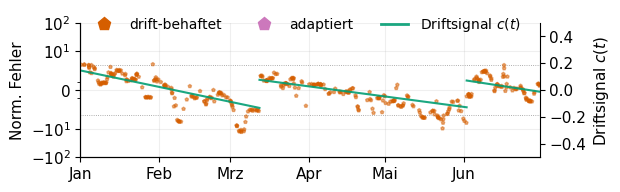

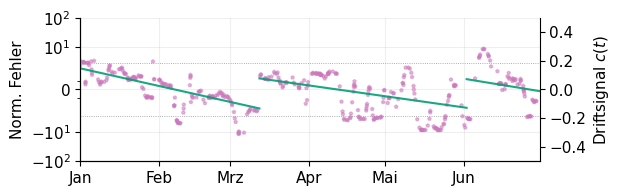

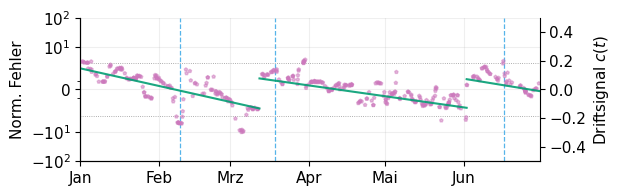

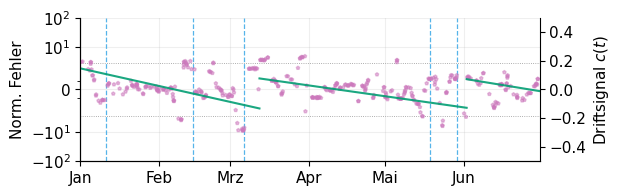

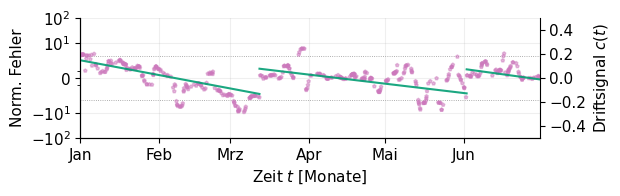

In [15]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

_mask_plot = (np.ones(N, bool) if PLOT_MONTHS is None else np.asarray(
    time_index < pd.Timestamp(PLOT_EPOCH) + pd.DateOffset(months=PLOT_MONTHS)))
t_plot = time_index[_mask_plot]
cd_plot = cd_signal[_mask_plot]
n_plot = len(t_plot)
# Ruecksprungstellen fuer den RMSE-Verlauf weiter unten aus drift_segment, nicht
# aus diff(c) > 0: c(t) ist gemessen und verrauscht (s. Zelle "Adaptionsstrom").
cut = np.flatnonzero(np.diff(drift_segment[_mask_plot]) > 0) + 1

rng_plot = np.random.default_rng(SEED)

PANELS = [("baseline", "Baseline"), ("blind", "Blind"),
          ("informed", "Informed"), ("combined", "Combined"),
          ("blind_rec", "Blind+Rec")]

for k, (key, title) in enumerate(PANELS):
    res = seed_results[_medoid][key]
    role = "drift_afflicted" if key == "baseline" else "adapted"
    label = "drift-behaftet" if key == "baseline" else "adaptiert"

    fig, ax, ax2 = ts.error_timeseries(
        t_plot,
        [(np.asarray(res["errors_norm"], float)[_mask_plot], role, label)],
        cd=cd_plot,
        detections=[t_plot[d] for d in res["detect_steps"] if d < n_plot],
        xlabel="Zeit $t$ [Monate]" if k == len(PANELS) - 1 else None,
        cd_label="Driftsignal $c(t)$",
        ylim=PLOT_YLIM, cd_amp=0.5, cd_tick_step=0.2,
        frac=PLOT_FRAC, rng=rng_plot,
        legend_series=[("drift_afflicted", "drift-behaftet"), ("adapted", "adaptiert")],
        legend=dict(bbox_to_anchor=[0.49, 1.15], loc="upper center", ncols=3) if k == 0 else False,
    )
    fig.tight_layout()
    # Immer schreiben, auch aus dem Cache: sonst bleiben die stabilen .pgf auf
    # dem Stand eines frueheren Laufs stehen, waehrend JSON und TeX schon die
    # neue id tragen. publish() legt die Archivkopie ohnehin nur an, wenn sie fehlt.
    plot_store.save_figure(fig, f"adaptation_{key}", adapt_cfg, final=IS_FINAL,
                           savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
    plt.show()

## RMSE-Verlauf der Strategien

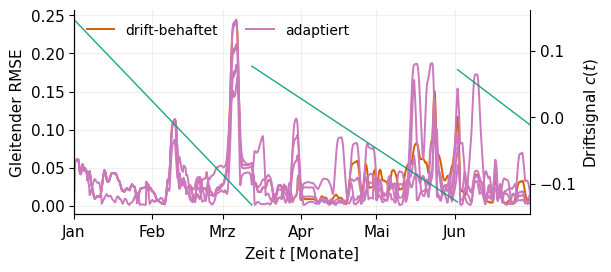

In [16]:
from matplotlib import dates as mdates
from src.utils import thesis_style as ts

WIN = max(10, 86400 // STEP_S)

fig, ax = plt.subplots(figsize=(ts.fig_width(), ts.fig_width(0.45)))

_adapt_labeled = False
for key, title in PANELS:
    e = pd.Series(np.asarray(seed_results[_medoid][key]["errors"], float), index=time_index)
    rmse_roll = np.sqrt((e ** 2).rolling(WIN, min_periods=1).mean())
    rmse_roll = rmse_roll[_mask_plot]
    if key == "baseline":
        _col, _lab = ts.C["drift_afflicted"], "drift-behaftet"
    else:
        _col = ts.C["adapted"]
        _lab = "adaptiert" if not _adapt_labeled else None
        _adapt_labeled = True
    ax.plot(rmse_roll.index, rmse_roll.values, color=_col, linewidth=1.4, label=_lab)

ax2 = ax.twinx()
for i, (a, b) in enumerate(zip(np.r_[0, cut], np.r_[cut, len(cd_plot)])):
    ax2.plot(t_plot[a:b], cd_plot[a:b], **ts.line("drift_signal", linewidth=1.0))
ax2.set_ylabel("Driftsignal $c(t)$")
ax2.spines["right"].set_visible(True)
ax2.spines["top"].set_visible(False)

ax.set_ylabel("Gleitender RMSE")
ax.set_xlabel("Zeit $t$ [Monate]")
ax.margins(x=0)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", ncol=2, frameon=False)
fig.tight_layout()
plt.show()

## Numerische Auswertung

In [17]:
def _strategy_stats(res, c, rmse_baseline):
    e = np.asarray(res["errors"], float)
    c = np.asarray(c, float)
    rmse = float(np.sqrt(np.mean(e ** 2)))
    return dict(
        rmse=rmse,
        bias=float(np.mean(e)),
        sigma=float(np.std(e)),
        corr_abs=float(np.corrcoef(np.abs(e), np.abs(c))[0, 1]),
        n_train=int(len(res["train_steps"])),
        n_detect=int(len(res["detect_steps"])),
        n_reject=int(len(res.get("reject_steps", []))),
        n_recall=float(np.mean(res.get("recall_counts") or [0.0])),
        rmse_improvement=float(1.0 - rmse / rmse_baseline) if rmse_baseline else 0.0,
    )

# Kennzahlen ueber ALLE Seeds (Zelle "Seed-Robustheit") statt nur des Haupt-Seeds.
# Je Seed die Strategie-Statistik berechnen (RMSE-Verbesserung seed-intern gegen
# die eigene Baseline) und anschliessend zu Mittelwert und Streuung aggregieren.
_METRIC_COLS = ["rmse", "bias", "sigma", "corr_abs",
                "n_train", "n_detect", "n_reject", "n_recall", "rmse_improvement"]
_rows = [k for k, _ in PANELS]

_per_seed = {}
for _sd, _r in seed_results.items():
    _rb = float(np.sqrt(np.mean(np.asarray(_r["baseline"]["errors"], float) ** 2)))
    _per_seed[_sd] = {k: _strategy_stats(_r[k], cd_signal, _rb) for k in _rows}

# je Strategie ein (Seeds x Kennzahlen)-Block -> Mittelwert/Std ueber die Seeds
_stack = {row: pd.DataFrame([_per_seed[sd][row] for sd in seed_results])[_METRIC_COLS]
          for row in _rows}
stats_mean = pd.DataFrame({row: _stack[row].mean()       for row in _rows}).T[_METRIC_COLS]
stats_std  = pd.DataFrame({row: _stack[row].std(ddof=1)  for row in _rows}).T[_METRIC_COLS]

# stats = Seed-Mittel; treibt Tabelle/JSON/Makros. Die Abbildungen nutzen weiterhin
# den Medoid-Seed ueber seed_results[_medoid] (illustrative Zeitreihen).
stats = stats_mean

pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(f"Kennzahlen als Mittelwert ueber {len(seed_results)} Seeds:")
print(stats_mean.to_string())
print("\nStreuung (Std ueber Seeds):")
print(stats_std.to_string())

Kennzahlen als Mittelwert ueber 50 Seeds:
             rmse       bias   sigma  corr_abs  n_train  n_detect  n_reject  n_recall  rmse_improvement
baseline  0.03978   -0.01132 0.03813    0.4925        0         0         0         0                 0
blind     0.07079   0.002047 0.07045   0.09516        8         0      1.52         0           -0.7797
informed  0.04136  -0.008646 0.03958    0.3804    32.46      9.18      4.34         0           -0.0399
combined  0.03371 -0.0003224 0.03371     0.214    194.1     25.34     16.24         0            0.1524
blind_rec 0.03651  0.0005959 0.03649    0.1554       16         0      0.04     889.4           0.08205

Streuung (Std ueber Seeds):
               rmse      bias     sigma  corr_abs  n_train  n_detect  n_reject  n_recall  rmse_improvement
baseline          0         0 7.009e-18         0        0         0         0         0                 0
blind       0.01685  0.005941   0.01715    0.1548        0         0     2.644         0   

## Seed-Robustheit — Verteilungsplot

RMSE-Verteilung je Strategie über alle Seeds als Violin + Box (`ts.violin_box`, Styling via `fig_width`). Baseline bleibt als deterministische Referenz aus dem Plot heraus und steht im Titel.

c:\git\process_optimization_concept_drift\.venv\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


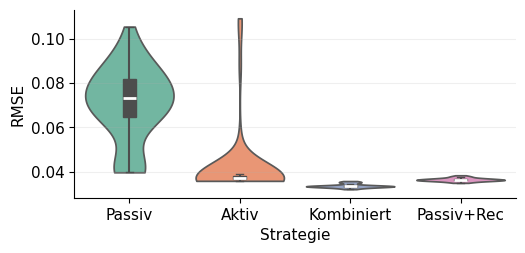

In [18]:
# Robustheits-Plot: Violin + Box (RMSE-Verteilung je Strategie ueber alle Seeds).
# Verteilungsplot ueber den arbeitsweit einheitlichen Helfer ts.violin_box; Styling
# via fig_width wie im uebrigen Notebook. Baseline bleibt draussen (deterministisch)
# und steht im Titel. Sinnvoll ab ~50 Seeds (N_SEED_RUNS), damit die KDE traegt.
import pandas as pd
from src.utils import thesis_style as ts

ts.fig_width()
_order = ["blind", "informed", "combined", "blind_rec"]
_labels = {"blind": "Passiv", "informed": "Aktiv", "combined": "Kombiniert", "blind_rec": "Passiv+Rec"}
_seeds = list(seed_results)
_long = pd.DataFrame({
    "Strategie": np.repeat([_labels[s] for s in _order], len(_seeds)),
    "RMSE": np.concatenate([seed_rmse.loc[s, _seeds].to_numpy(float) for s in _order]),
})

fig, ax = plt.subplots(figsize=(ts.fig_width(0.85), ts.fig_width(0.42)))
ts.violin_box(_long, "Strategie", "RMSE", order=[_labels[s] for s in _order],
              palette=ts.SET2[:len(_order)], ax=ax)
ax.set_ylabel("RMSE"); ax.set_xlabel("Strategie")
fig.tight_layout()
if IS_FINAL:
    plot_store.save_figure(fig, "adaptation_seed_violin", adapt_cfg,
                           final=IS_FINAL, savefig_kwargs={"dpi": 300},
                           archive_kwargs={"dpi": 300})
plt.show()

## Ergebnisse speichern

In [19]:
from src.utils import results_export as rx

# Kennzahlen sind nun Seed-Mittel -> durchgaengig als Dezimalzahl, auch
# n_train/n_detect/n_reject. Mittelwert -> "strategies", Streuung ueber die Seeds
# -> "strategies_std".
_keys = [(k, k, "num") for k in ["rmse", "bias", "sigma", "corr_abs",
                                 "n_train", "n_detect", "n_reject", "n_recall", "rmse_improvement"]]

doc = (rx.ResultDoc()
   .integer("n_samples", N)
   .integer("step_seconds", STEP_S)
   .set("samples_per_hour", SAMPLES_PER_H)
   .set("stride", int(STRIDE))
   .set("reset_indices", reset_pos)
   .integer("n_seeds", len(seed_results))
   .set("detectors_screened", list(DETECTORS))
   .set("informed_detector", BEST_DETECTOR)
   .set("screening", {d: {"rmse": float(v["rmse"]), "n_train": int(v["n_train"])}
                      for d, v in screening.items()})
   .set("config", ADAPT_CFG)
   .set("tuning", {
       "step_tune_seconds": int(STEP_TUNE_S),
       "n_trials": N_TRIALS,
       "weights": list(TUNE_WEIGHTS),
       "best_params": best_adapt_params,
   })
   .set("cooldown", {"tuned": True, "x_range": [0.0, 60.0], "t_stat_points": float(T_stat)})
   .set("applied_config", applied_cfg)
   .stats(stats_mean, _keys, into="strategies",     rows=[k for k, _ in PANELS])
   .stats(stats_std,  _keys, into="strategies_std", rows=[k for k, _ in PANELS]))

if "seed_rmse" in dir():
    doc.set("seed_eval", {
        "seeds": [int(s) for s in SEEDS],
        "rmse": {s: {"mean": float(seed_rmse.loc[s, "mean"]),
                     "std": float(seed_rmse.loc[s, "std"])} for s in STRATEGIES},
    })

doc.save(res_store, "adaptation", adapt_cfg, final=IS_FINAL,
         parents={"model": scored_error_cfg.id})

Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\tep_adaptation.json


'C:\\git\\process_optimization_concept_drift\\results\\tep_adaptation.json'

In [20]:
from src.utils import latex_export as lx

mx = lx.MacroExport("automatisch erzeugt aus tep_adaptation.ipynb - nicht manuell editieren")

mx.comment("Parameter (Hash-relevant)")
mx.param("tepadaptTa",     STEP_S,      unit=r"\second")
mx.param("tepadaptTaTune", STEP_TUNE_S, unit=r"\second")
mx.param("tepadaptNPoints", N)
mx.param("tepadaptChunk",   CHUNK)

mx.comment("Ergebnisse (Adaptionskennzahlen je Strategie; Mittelwert und Std ueber alle Seeds)")
mx.integer("tepadaptNSeeds", len(seed_results))
_name_map = {"baseline": "Baseline", "blind": "Blind",
             "informed": "Informed", "combined": "Combined", "blind_rec": "BlindRec"}
# (Spalte, Suffix, Nachkommastellen). Nachtrainings/Detektionen sind als Seed-Mittel
# nicht mehr ganzzahlig und werden daher mit einer Nachkommastelle ausgegeben. Zu
# jeder Kennzahl wird zusaetzlich die Streuung ueber die Seeds als ...Std-Makro
# erzeugt (fuer die "Mittelwert +/- Std"-Darstellung in der Tabelle).
_keys = [("rmse", "Rmse", 3), ("bias", "Bias", 3), ("sigma", "Sigma", 3),
         ("corr_abs", "CorrAbs", 2), ("rmse_improvement", "Improve", 3),
         ("n_train", "NTrain", 1), ("n_detect", "NDetect", 1), ("n_recall", "NRecall", 1)]
for k, _ in PANELS:
    m = _name_map[k]
    for col, suf, nd in _keys:
        mx.num(f"tepadapt{m}{suf}",    stats_mean.loc[k, col], nd)
        mx.num(f"tepadapt{m}{suf}Std", stats_std.loc[k, col],  nd)

mx.save(res_store, "adaptation", adapt_cfg, final=IS_FINAL)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\tep_adaptation.tex

% automatisch erzeugt aus tep_adaptation.ipynb - nicht manuell editieren

% Parameter (Hash-relevant)
\newcommand{\tepadaptTa}{\SI{1800}{\second}}
\newcommand{\tepadaptTaTune}{\SI{10800}{\second}}
\newcommand{\tepadaptNPoints}{34849}
\newcommand{\tepadaptChunk}{48}

% Ergebnisse (Adaptionskennzahlen je Strategie; Mittelwert und Std ueber alle Seeds)
\newcommand{\tepadaptNSeeds}{50}
\newcommand{\tepadaptBaselineRmse}{0{,}040}
\newcommand{\tepadaptBaselineRmseStd}{0{,}000}
\newcommand{\tepadaptBaselineBias}{-0{,}011}
\newcommand{\tepadaptBaselineBiasStd}{0{,}000}
\newcommand{\tepadaptBaselineSigma}{0{,}038}
\newcommand{\tepadaptBaselineSigmaStd}{0{,}000}
\newcommand{\tepadaptBaselineCorrAbs}{0{,}49}
\newcommand{\tepadaptBaselineCorrAbsStd}{0{,}00}
\newcommand{\tepadaptBaselineImprove}{0{,}000}
\newcommand{\tepadaptBaselineImproveStd}{0{,}000}
\newcommand{\tepadaptBaselineNTrain}{0{,}0}
\newcommand{\tepa

'C:\\git\\process_optimization_concept_drift\\results\\tep_adaptation.tex'